<a href="https://colab.research.google.com/github/SulaimanAlkoryshy/SMS-Spam-Classification-ML/blob/main/SmsSpamClassifier_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Machine Learning Project
#SMS Spam Classification using Machine Learning


#Step 1: Explaining the Problem
In modern digital communication, SMS continues to play a vital role in both personal and business interactions. but, the broad use of SMS has also led to a rise in spam messages, unwanted texts that may contain a simple annoyance or serious security threats such as phishing and fraud.
This raises a high need for an automated solution that can distinguish between  messages ham and spam.

So, our objective is to design and implement a machine learning model that capable of classifying SMS messages.

by Using the ‘SMS Spam Collection’ famous dataset from Kaggle, which contains thousands of labeled examples, our approach includes:

Data Preparation: Ensuring data quality by removing duplicate values and dropping unnecessary empty columns.

Data Wrangling: make Label Encoding that transform the categorical labels ham and spam into a binary numerical format suitable for machine learning.

Feature Extraction: use TF-IDF Vectorization that converts raw text messages into numerical features.

Modeling: training a Multinomial Naive Bayes Classifier, a probabilistic model that we chose for its high performance in text classification tasks.



#Step 2: Gathering Data
In this step, we have selected the ‘SMS Spam Collection’ dataset from Kaggle. To make collaboration easier for our group on Google Colab, we use the opendatasets library. This method contributes to letting us download the dataset directly using code and API credentials, rather than uploading files manually every time.

After downloading dataset, we have used the Pandas library to read the CSV file. We particularly use 'latin-1' encoding because SMS messages often contain special characters that standard encoding cannot read.
Then, we inspect the dataset by displaying a random sample and examine it shape and summary information to ensure the data is loaded correctly and ready for the cleaning step.


In [ ]:
!pip install opendatasets --quiet

import opendatasets as od
import pandas as pd

#Download the Dataset and enter your username in kaggle and api token from kaggle
od.download("https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset")

#Read the Data, Loading the csv file with 'latin-1' encoding
df = pd.read_csv('sms-spam-collection-dataset/spam.csv', encoding='latin-1')
print("Dataset loaded successfully!")

#Display 5 random samples to understand the data
print(f"\nRandom Sample of 5 rows:\n{df.sample(5)}")
df.sample(5)

# Check how many entries in our dataset
print(f"\nDataset Shape: {df.shape}")

print("\nDataset overview:")
print(df.info())

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sulaimanalkoryshy
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset


100%|██████████| 211k/211k [00:00<00:00, 206MB/s]


Dataset loaded successfully!

Random Sample of 5 rows:
       v1                                                 v2 Unnamed: 2  \
1921  ham          No current and food here. I am alone also        NaN   
1983  ham  I wnt to buy a BMW car urgently..its vry urgen...        NaN   
3202  ham  Haha... Yup hopefully  we will lose a few kg b...        NaN   
3230  ham                 No plm i will come da. On the way.        NaN   
3385  ham  Oops - am at my mum's in somerset... Bit far! ...        NaN   

     Unnamed: 3 Unnamed: 4  
1921        NaN        NaN  
1983        NaN        NaN  
3202        NaN        NaN  
3230        NaN        NaN  
3385        NaN        NaN  

Dataset Shape: (5572, 5)

Dataset overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unn

#Step 3: Data Preparation
In this phase, we must ensure our dataset is clean and structured well for analysis.
As Real-world data often contains noise and redundancies that must be handled before training a model.
In the beginning we removing unnecessary columns that contain mostly null values and that do not provide any useful information for our classification task.

Then, we enhance the readability of the dataset by renaming the default column names. We change v1 to Label that indicates if the message is spam or ham and v2 to Text that is the actual message content. We also perform a check for missing values to confirm the data quality. Finally, and most importantly, we handle data duplicates. Duplicate messages can bias the machine learning model.
We check the count of duplicate rows and then remove them to ensure that our model learns from unique data. We also perform a final check for missing values to confirm the data quality.


In [ ]:
#Drop unnecessary columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

#Rename columns
df.rename(columns={'v1': 'Label', 'v2': 'Text'}, inplace=True)
print(f"First rows after drop unnecessary columns and rename columns:\n{df.head()}")

#Check for Missing Values
print(f"\nMissing values:\n{df.isnull().sum()}")

#Check duplicate values
print(f"\nDuplicate rows: {df.duplicated().sum()}")

#Remove Duplicate values
df = df.drop_duplicates(keep='first')

#Check shape of dataset after removed duplicates values
print(f"\nDataset shape after removing duplicates values:{df.shape}")

First rows after drop unnecessary columns and rename columns:
  Label                                               Text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Missing values:
Label    0
Text     0
dtype: int64

Duplicate rows: 403

Dataset shape after removing duplicates values:(5169, 2)


#Step 4: Data Wrangling
In this step, we transformed the categorical target labels (“ham” and “spam”) into numeric values so the model could process them correctly. Using the LabelEncoder from scikit-learn, we converted “ham” to 0 and “spam” to 1. This encoding is necessary because most machine learning algorithms can only interpret numerical input. The transformation ensures that the model can distinguish between both classes and calculate probabilities accordingly. This step also helps reduce any ambiguity between text categories and prepares the dataset for feature extraction and vectorization in the next phase. After encoding, the dataset becomes completely numerical, with two columns: Label (0 or 1) and Text (SMS message content), ready for text feature engineering.

In [ ]:
from sklearn.preprocessing import LabelEncoder

#Label Encoding to Transforming Categorical Data
#We convert 'ham' to 0 and 'spam' to 1
encoder = LabelEncoder()
df['Label'] = encoder.fit_transform(df['Label'])

print("Data Wrangling Completed.")
print(df.head())

Data Wrangling Completed.
   Label                                               Text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


#Step 5: Analyze Data
Prior to developing any machine learning model, the data analysis process concentrates on comprehending patterns, distributions, and contrasts within the dataset. At this point, a new column called num_characters is created by using the len() method to determine the number of characters in each message. Because spam and ham messages frequently have different lengths, this functionality is helpful. You can then view the mean, median, and standard deviation for both classes by using groupby and describe to create a statistical summary. Visualizations are also made to better understand the data. The overall class distribution is displayed on a pie chart, which makes it easier to spot any disparity between spam and ham messages. Histograms also display patterns of message length, illustrating the differences in text size between the two groups.

Statistical Summary Ham vs Spam length:
        count        mean        std   min    25%    50%    75%    max
Label                                                                 
0      4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
1       653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0




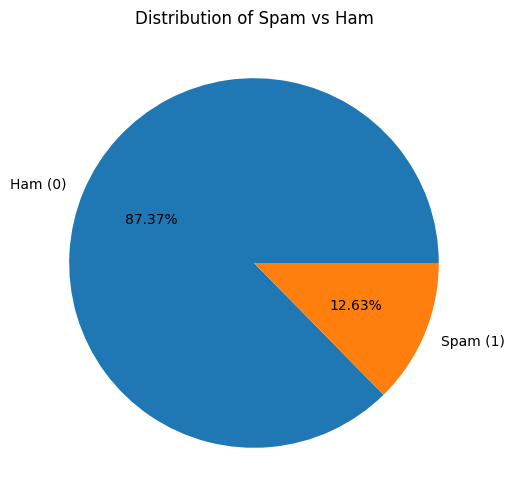

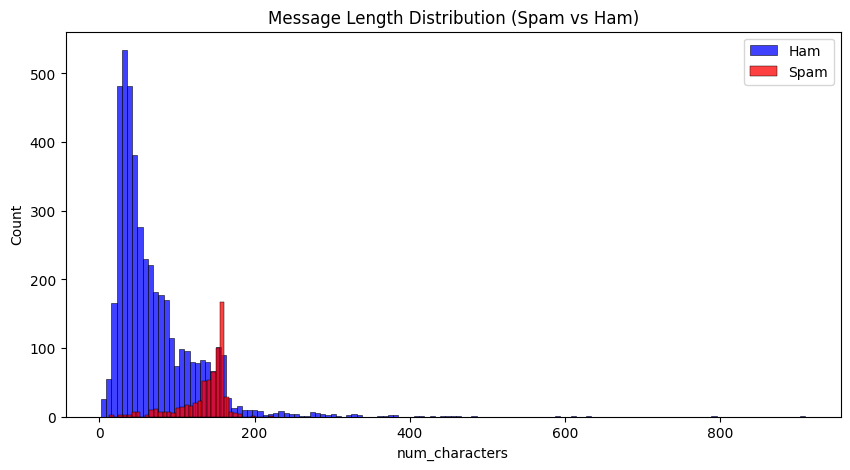

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Calculate number of characters
df['num_characters'] = df['Text'].apply(len)

#Summarize data using mean, median, std
print("Statistical Summary Ham vs Spam length:")
print(df.groupby('Label')['num_characters'].describe())
print("\n")

#Pie Chart for Class Distribution
plt.figure(figsize=(6, 6))
plt.pie(df['Label'].value_counts(), labels=['Ham (0)', 'Spam (1)'], autopct="%0.2f%%")
plt.title("Distribution of Spam vs Ham")
plt.show()
print("\n")

#Histogram for Message Lengths
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Label'] == 0]['num_characters'], color='blue', label='Ham')
sns.histplot(df[df['Label'] == 1]['num_characters'], color='red', label='Spam')
plt.title("Message Length Distribution (Spam vs Ham)")
plt.legend()
plt.show()



#Step 6: Train Model
In order to create a machine learning model that can identify spam, the training stage transforms text messages into numerical characteristics. First, TF-IDF Vectorization is implemented using TfidfVectorizer, which turns the text into weighted numerical values that signify how important each word is within the dataset. The vocabulary is restricted to the most informative terms when max_features=3000 is set. The labels (ham or spam) are kept in y, while the altered data is kept in X. To guarantee that the model can be assessed later, the dataset is then divided into training and testing sets using an 80/20 ratio. The training data is then used to train the Multinomial Naive Bayes classifier, which is ideal for text classification, using.fit(). The model is prepared to offer predictions after training is finished.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

#TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['Text']).toarray()
y = df['Label'].values

#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

#Train the Model
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


#Step 7: Test Model
The testing phase assesses the performance of the trained model on data that it has not been trained on. Based on the training of the Naive Bayes classifier, predictions on mnb.predict(X_test) were made to obtain y_pred, which includes the predicted labels for the test messages by the model. Performance was measured through a number of key metrics. Accuracy gives the overall percentage of correctly predicted items and gives an overall view of the model's performance. Precision, however, is more important in this case, because one would want to know how many of the messages predicted as spam are actually spam to avoid too many false alarms. A more detailed view is provided by the classification report, including precision, recall, and F1-score for each class. These metrics let you know not only how often the model is correct but also how reliable it is when it identifies spam specifically. This evaluation step helps ensure that the model performs well and is ready for practical use.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score

#Make Predictions
y_pred = mnb.predict(X_test)

#Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy Score: {accuracy*100:.2f}%")
print(f"Precision Score: {precision*100:.2f}%")

#Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 97.29%
Precision Score: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       1.00      0.80      0.89       138

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.97      0.97      0.97      1034

